In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/task2_output.csv")

df.head()

df.info()

df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   review            1478 non-null   str    
 1   rating            1478 non-null   int64  
 2   date              1478 non-null   str    
 3   bank              1478 non-null   str    
 4   source            1478 non-null   str    
 5   clean_text        1402 non-null   str    
 6   sentiment_label   1478 non-null   str    
 7   sentiment_score   1478 non-null   float64
 8   identified_theme  1478 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 104.1 KB


,review,rating,date,bank,source,clean_text,sentiment_label,sentiment_score,identified_theme
count,1478,1478.000000,1478,1478,1478,1402,1478,1478.000000,1478
unique,1136,NaN,358,3,1,988,2,NaN,6
top,good,NaN,2026-04-22,BOA,Google Play,good,POSITIVE,NaN,Other
freq,102,NaN,33,499,1478,126,986,NaN,1335
mean,NaN,3.858593,NaN,NaN,NaN,NaN,NaN,0.973143,NaN
std,NaN,1.651295,NaN,NaN,NaN,NaN,NaN,0.072483,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.503687,NaN
25%,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,0.996024,NaN
50%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,0.999687,NaN
75%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,0.999816,NaN


Sentiment Count Table

In [2]:
sentiment_counts = (
    df.groupby(["bank", "sentiment_label"])
      .size()
      .reset_index(name="count")
)

sentiment_counts

,bank,sentiment_label,count
0,BOA,NEGATIVE,202
1,BOA,POSITIVE,297
2,CBE,NEGATIVE,132
3,CBE,POSITIVE,349
4,Dashen,NEGATIVE,158
5,Dashen,POSITIVE,340


Sentiment Distribution

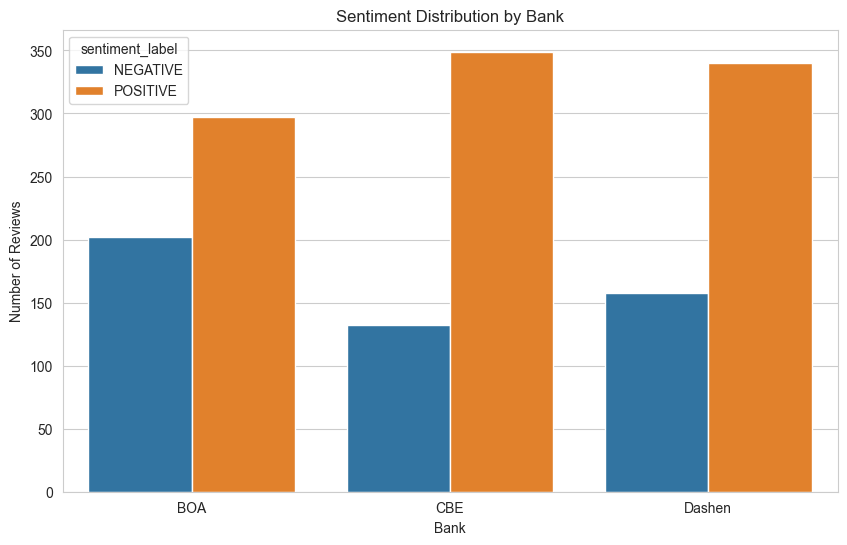

In [3]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=sentiment_counts,
    x="bank",
    y="count",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()

Average Rating by Bank

In [4]:
avg_ratings = (
    df.groupby("bank")["rating"]
      .mean()
      .reset_index()
)

avg_ratings

,bank,rating
0,BOA,3.565130
1,CBE,4.087318
2,Dashen,3.931727


Ratings

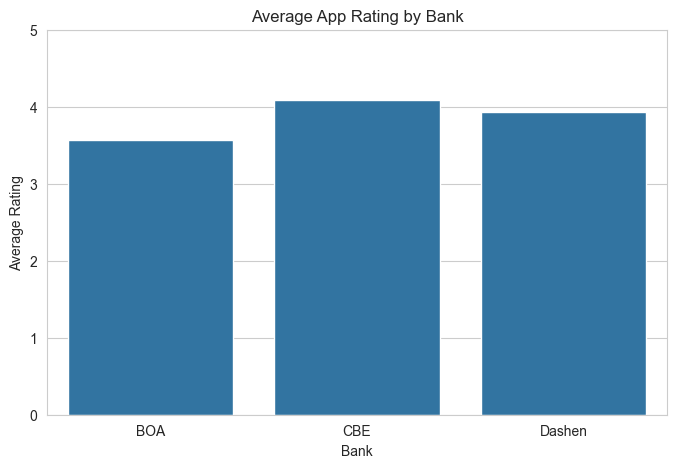

In [5]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_ratings,
    x="bank",
    y="rating"
)

plt.title("Average App Rating by Bank")
plt.xlabel("Bank")
plt.ylabel("Average Rating")

plt.ylim(0, 5)

plt.show()

Theme Frequency Analysis

Themes

In [6]:
theme_counts = (
    df["identified_theme"]
      .value_counts()
      .reset_index()
)

theme_counts.columns = ["theme", "count"]

theme_counts

,theme,count
0,Other,1335
1,Performance Issues,35
2,Transaction Performance,33
3,UI & Design,31
4,App Stability Issues,22
5,Account Access Issues,22


Theme Frequency

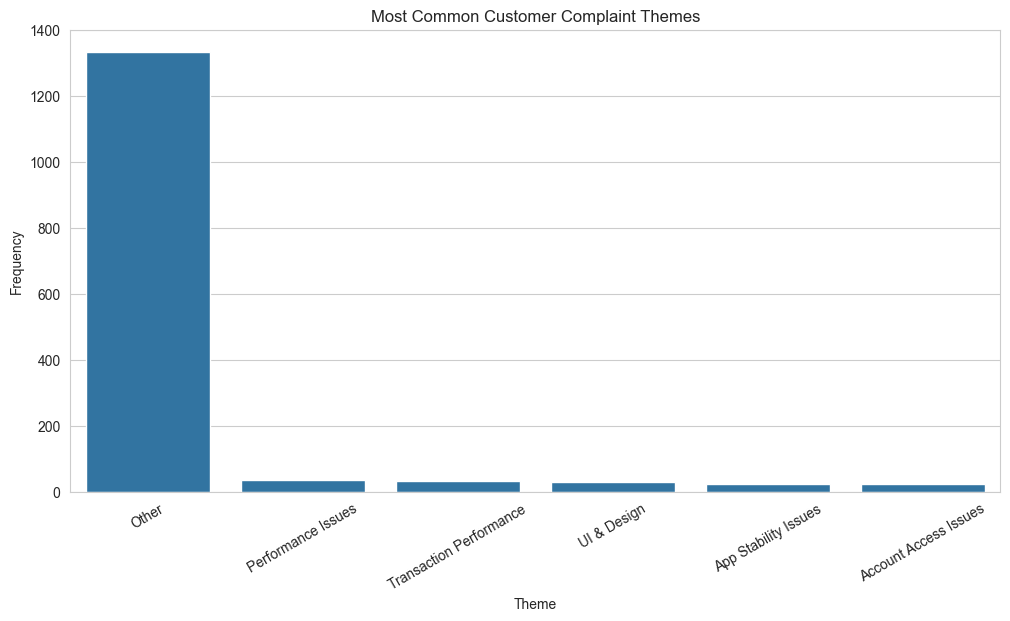

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=theme_counts,
    x="theme",
    y="count"
)

plt.title("Most Common Customer Complaint Themes")
plt.xlabel("Theme")
plt.ylabel("Frequency")

plt.xticks(rotation=30)

plt.show()

Sentiment vs Rating

Rating Distribution by Sentiment

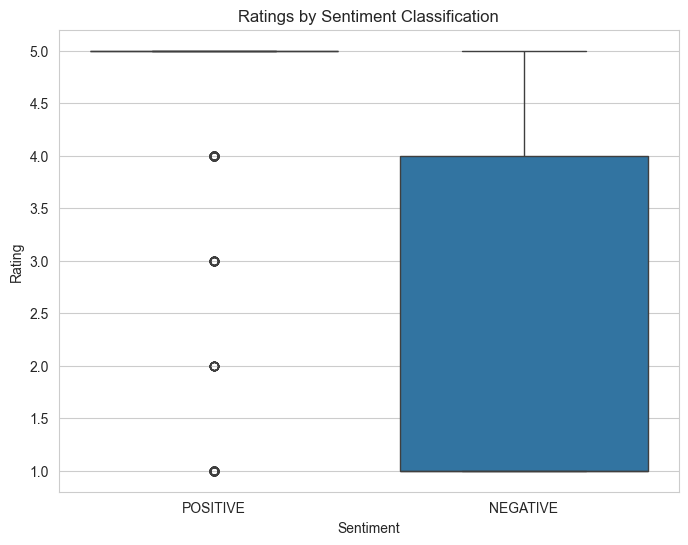

In [8]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="sentiment_label",
    y="rating"
)

plt.title("Ratings by Sentiment Classification")
plt.xlabel("Sentiment")
plt.ylabel("Rating")

plt.show()

Word Cloud

In [12]:
from wordcloud import WordCloud

text = " ".join(
    df["clean_text"]
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

Satisfaction Drivers

## Major Satisfaction Drivers

Positive reviews frequently highlighted:

- Fast transaction processing
- Easy account access
- Convenient mobile banking services
- Improved digital accessibility
- Simple user interface design

## Major Customer Pain Points

Negative reviews frequently mentioned:

- OTP failures
- Login issues
- Slow application performance
- App crashes
- Transaction interruptions

## Recommendations for CBE

- Improve authentication reliability
- Reduce login failures
- Optimize transaction response times

## Recommendations for BOA

- Improve app stability
- Reduce crash frequency
- Enhance customer support responsiveness

## Recommendations for Dashen

- Continue improving user interface consistency
- Improve transaction reliability during peak hours

# Final Insights Summary

The analysis identified significant relationships between application reliability and customer satisfaction.

Key findings include:

- Authentication and OTP issues are major dissatisfaction drivers
- Positive reviews strongly correlate with transaction speed and usability
- Banks with better app stability receive higher sentiment scores and ratings
- Infrastructure reliability appears central to customer retention